<a href="https://colab.research.google.com/github/MinaNik229/analisis-sentimiento-restaurantes/blob/main/Sesi%C3%B3n_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TEMA 9**

# Conceptos Clave de Visión por Computador

## 1. Clasificación vs. Detección y Segmentación
* **Clasificador (ViT - Vision Transformer):** Su objetivo es responder a la pregunta **¿Qué hay en la imagen?** asignando una etiqueta global a toda la imagen (por ejemplo, "tabby cat"). No nos dice dónde están los gatos, ni cuántos hay, solo que la imagen contiene esa clase.
* **Detector/Segmentador (YOLO):** Su objetivo es responder a **¿Qué hay y dónde está?**. Identifica múltiples objetos de forma individual dentro de una misma escena, dibujando cajas delimitadoras (*bounding boxes*) en el caso de la detección (como YOLOv8), o delimitando el contorno exacto a nivel de píxel si fuera un segmentador.

## 2. Importancia de los Modelos Preentrenados
* **Ahorro de Tiempo y Recursos:** Entrenar un modelo como Vision Transformer desde cero requiere millones de imágenes y semanas de cómputo en supercomputadoras. Al usar un modelo preentrenado (por ejemplo, en ImageNet), heredamos todo ese "conocimiento" al instante.
* **Transfer Learning:** Permiten usarse de forma directa para tareas generales o ajustarse (*fine-tuning*) con un conjunto de datos propio muy pequeño para especializarlos en tareas específicas con alta precisión.

## 3. ¿Cómo se usan?
1. **Preprocesamiento:** Se transforma la imagen de entrada (redimensionar, normalizar) usando un procesador especializado para que coincida con el formato con el que el modelo fue entrenado.
2. **Inferencia:** Se pasa la imagen procesada a través de la red neuronal para obtener vectores numéricos de salida (logits).
3. **Postprocesamiento:** Se interpretan estos valores (por ejemplo, aplicando la función *argmax* para obtener la clase con mayor puntuación o dibujando cajas y etiquetas en la imagen).

In [ ]:
# Instalar las librerías necesarias para el procesamiento y YOLOv8
!pip install transformers datasets torch torchvision ultralytics --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 9.7 MB/s eta 0:00:00


In [ ]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests
import torch

# 1. Definir el modelo preentrenado a utilizar (Vision Transformer de Google)
model_name = "google/vit-base-patch16-224"

# 2. Cargar el procesador de imágenes (redimensiona y normaliza la imagen de entrada)
feature_extractor = ViTImageProcessor.from_pretrained(model_name)

# 3. Cargar el modelo preentrenado para clasificación de imágenes
model = ViTForImageClassification.from_pretrained(model_name)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

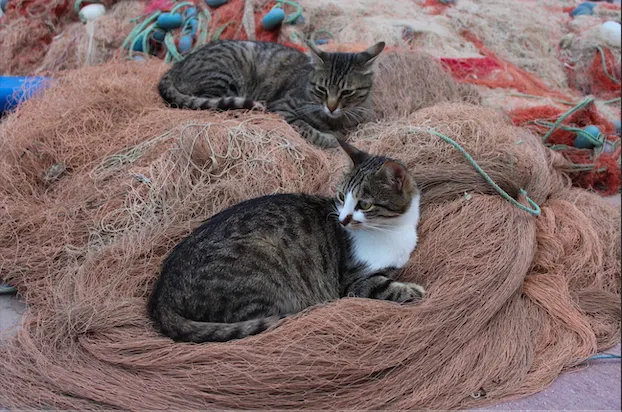

In [ ]:
# 1. Definir la URL de la imagen de prueba (unos gatos)
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/cats.png"

# 2. Descargar la imagen y convertirla a formato RGB
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# 3. Preprocesar la imagen para adaptarla al formato que espera el modelo (tensores de PyTorch)
inputs = feature_extractor(images=image, return_tensors="pt")

# 4. Pasar la imagen preprocesada por el modelo sin calcular gradientes (inferencia)
outputs = model(**inputs)

# 5. Obtener las predicciones (logits) y buscar la clase con la probabilidad más alta
logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()

# 6. Mapear el índice predicho a su etiqueta textual correspondiente y mostrar el resultado
print("Predicción:", model.config.id2label[predicted_class_idx])

Predicción: tabby, tabby cat


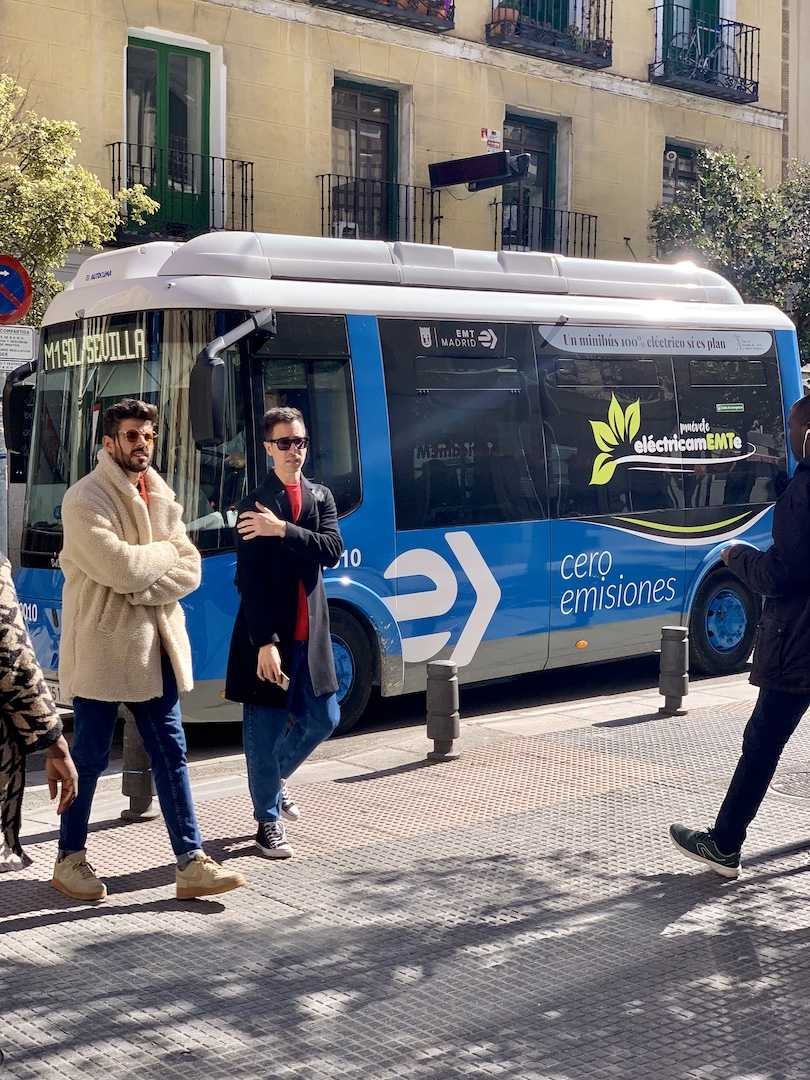

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 22.0ms
Speed: 162.1ms preprocess, 22.0ms inference, 103.7ms postprocess per image at shape (1, 3, 640, 480)


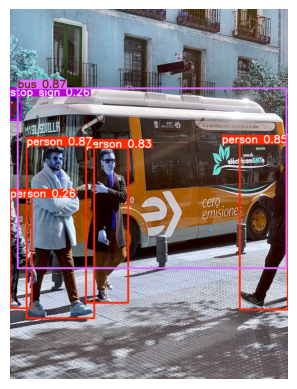

In [ ]:
# Asegurar que la librería ultralytics esté instalada
import sys
!{sys.executable} -m pip install ultralytics --quiet

from ultralytics import YOLO
from IPython.display import display
import matplotlib.pyplot as plt

# 1. Cargar el modelo preentrenado YOLOv8 nano (diseñado para detección/segmentación rápida)
model_yolo = YOLO("yolov8n.pt")

# 2. Ejecutar la detección de objetos sobre una imagen en línea
results = model_yolo("https://ultralytics.com/images/bus.jpg")

# 3. Dibujar las cajas delimitadoras (bounding boxes) y etiquetas sobre la imagen
img = results[0].plot()   # results[0] extrae el primer resultado de la lista

# 4. Mostrar la imagen resultante usando matplotlib sin ejes coordenados
plt.imshow(img)
plt.axis("off")
plt.show()

In [10]:
# ==========================================================================
# CELDA 1: Comparativa de Modelos de Análisis de Sentimiento (NLP)
# ==========================================================================
# Esta celda se encarga de evaluar tres modelos diferentes de Hugging Face
# utilizando un mismo conjunto de textos en español para medir su desempeño
# (predicciones y tiempo de procesamiento).
# ==========================================================================

# 1. Instalar librerías necesarias para ejecutar los transformadores de Hugging Face y PyTorch
!pip install transformers torch --quiet

# 2. Importar las librerías requeridas
from transformers import pipeline  # Facilita el uso de modelos preentrenados en una sola línea
import time                        # Nos permite medir con precisión el tiempo de ejecución

# 3. Definir el conjunto de datos manual en español (casos de prueba positivos, negativos y neutros)
texts = [
    "La película fue increíble, me encantó la historia",
    "No me gustó la actuación, fue muy mala",
    "El libro es interesante pero un poco largo",
    "La experiencia fue terrible, no lo recomiendo",
    "Me gustó mucho, volvería a verlo"
]

# 4. Definir un diccionario con los identificadores de los modelos públicos en Hugging Face
#    - nlptown/bert-base-multilingual-uncased-sentiment: Modelo basado en BERT para predecir estrellas (1 a 5).
#    - lxyuan/distilbert-base-multilingual-cased-sentiments-student: DistilBERT optimizado, rápido y ligero.
#    - cardiffnlp/twitter-xlm-roberta-base-sentiment: XLM-RoBERTa entrenado en tweets de múltiples idiomas.
models = {
    "BERT Multilingüe": "nlptown/bert-base-multilingual-uncased-sentiment",
    "DistilBERT Multilingüe": "lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    "RoBERTa Multilingüe": "cardiffnlp/twitter-xlm-roberta-base-sentiment"
}

# 5. Diccionario vacío para almacenar los resultados del análisis (predicciones y tiempos)
results = {}

# 6. Bucle para iterar y evaluar cada uno de los modelos
for name, model_name in models.items():
    print(f"\nModelo: {name}")

    # Inicializamos el pipeline de análisis de sentimiento con el modelo correspondiente
    classifier = pipeline("sentiment-analysis", model=model_name)

    # Medimos el tiempo justo antes de realizar la inferencia sobre la lista de textos
    start = time.time()
    outputs = classifier(texts)  # El modelo procesa y clasifica todos los textos
    elapsed = time.time() - start # Calculamos la diferencia de tiempo transcurrido

    # Guardamos los resultados (etiquetas, confianza y tiempo de inferencia)
    results[name] = {
        "outputs": outputs,
        "time": elapsed
    }

    # Imprimimos la clasificación y score de confianza obtenido para cada texto de prueba
    for text, out in zip(texts, outputs):
        print(f"- Texto: {text}")
        print(f"  → {out['label']} (confianza {out['score']:.2f})")

    print("Tiempo total:", round(elapsed, 2), "segundos")

# 7. Comparación rápida al final de la ejecución de la celda
print("\n--- COMPARACIÓN FINAL DE TIEMPOS ---")
for name, data in results.items():
    print(f"{name}: {data['time']:.2f} segundos")

# ==========================================================================
# EXPLICACIÓN DE LA SALIDA:
# Cada modelo clasifica los textos de forma diferente de acuerdo a cómo fue entrenado:
# - BERT Multilingüe suele devolver etiquetas de estrellas (p. ej. '1 star' o '5 stars').
# - DistilBERT y RoBERTa devuelven etiquetas directas de polaridad ('positive', 'negative', 'neutral').
# En términos de velocidad, DistilBERT (versión destilada/comprimida) es drásticamente
# más rápido que BERT y RoBERTa clásicos, demostrando el beneficio de usar modelos compactos.
# ==========================================================================


Modelo: BERT Multilingüe


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

- Texto: La película fue increíble, me encantó la historia
  → 5 stars (confianza 0.80)
- Texto: No me gustó la actuación, fue muy mala
  → 1 star (confianza 0.60)
- Texto: El libro es interesante pero un poco largo
  → 3 stars (confianza 0.62)
- Texto: La experiencia fue terrible, no lo recomiendo
  → 1 star (confianza 0.80)
- Texto: Me gustó mucho, volvería a verlo
  → 4 stars (confianza 0.37)
Tiempo total: 0.11 segundos

Modelo: DistilBERT Multilingüe


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

- Texto: La película fue increíble, me encantó la historia
  → positive (confianza 0.82)
- Texto: No me gustó la actuación, fue muy mala
  → negative (confianza 0.92)
- Texto: El libro es interesante pero un poco largo
  → positive (confianza 0.80)
- Texto: La experiencia fue terrible, no lo recomiendo
  → negative (confianza 0.86)
- Texto: Me gustó mucho, volvería a verlo
  → positive (confianza 0.89)
Tiempo total: 0.06 segundos

Modelo: RoBERTa Multilingüe


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

- Texto: La película fue increíble, me encantó la historia
  → positive (confianza 0.94)
- Texto: No me gustó la actuación, fue muy mala
  → negative (confianza 0.94)
- Texto: El libro es interesante pero un poco largo
  → neutral (confianza 0.49)
- Texto: La experiencia fue terrible, no lo recomiendo
  → negative (confianza 0.88)
- Texto: Me gustó mucho, volvería a verlo
  → positive (confianza 0.91)
Tiempo total: 0.18 segundos

--- COMPARACIÓN FINAL DE TIEMPOS ---
BERT Multilingüe: 0.11 segundos
DistilBERT Multilingüe: 0.06 segundos
RoBERTa Multilingüe: 0.18 segundos


--- TABLA DE TIEMPOS ---
                   Modelo  Tiempo (segundos)
0        BERT Multilingüe           0.108144
1  DistilBERT Multilingüe           0.057430
2     RoBERTa Multilingüe           0.178233
------------------------



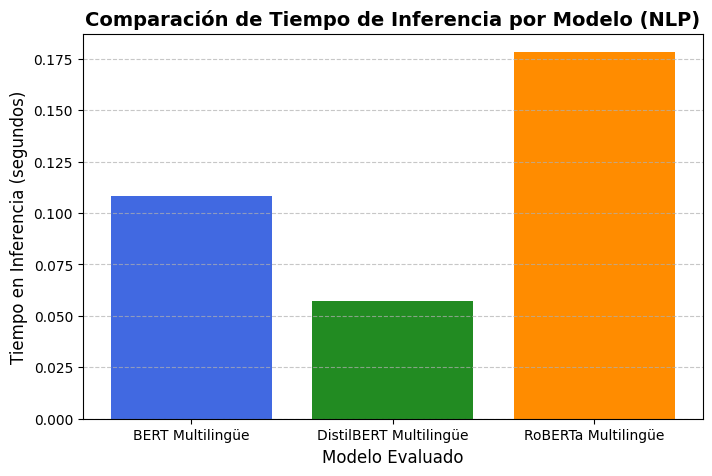

In [11]:
# ==========================================================================
# CELDA 2: Visualización y Análisis Comparativo de Tiempos
# ==========================================================================
# Esta celda recopila los tiempos registrados en la celda anterior y crea
# una visualización gráfica clara para facilitar la toma de decisiones.
# ==========================================================================

import pandas as pd             # Librería estándar para el manejo y estructura de datos en tablas
import matplotlib.pyplot as plt  # Librería para generar gráficos de alta calidad

# 1. Creamos un DataFrame de pandas a partir del diccionario de resultados guardado en memoria
#    Esto nos permite estructurar la información en columnas legibles (Modelo, Tiempo)
data = {
    "Modelo": list(results.keys()),
    "Tiempo (segundos)": [results[m]["time"] for m in results]
}

df = pd.DataFrame(data)

# 2. Mostramos en consola la tabla tabulada resultante de los datos recopilados
print("--- TABLA DE TIEMPOS ---")
print(df)
print("------------------------\n")

# 3. Configuramos los parámetros estéticos del gráfico de barras utilizando Matplotlib
plt.figure(figsize=(8, 5)) # Definimos el tamaño de la figura (ancho x alto)

# 4. Dibujamos el gráfico de barras asignando colores distintos a cada modelo para diferenciarlos visualmente
plt.bar(df["Modelo"], df["Tiempo (segundos)"], color=["royalblue", "forestgreen", "darkorange"])

# 5. Añadimos títulos y etiquetas claras a los ejes
plt.title("Comparación de Tiempo de Inferencia por Modelo (NLP)", fontsize=14, fontweight='bold')
plt.ylabel("Tiempo en Inferencia (segundos)", fontsize=12)
plt.xlabel("Modelo Evaluado", fontsize=12)

# 6. Agregamos una cuadrícula horizontal de fondo para facilitar la lectura visual de los valores exactos
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 7. Renderizamos y desplegamos el gráfico final en pantalla
plt.show()

# ==========================================================================
# EXPLICACIÓN DE LA SALIDA:
# - Tabla de Datos: Muestra exactamente los segundos numéricos que le tomó a cada modelo procesar los 5 textos.
# - Gráfico de Barras: Nos da una representación visual directa donde salta a la vista que el modelo 'DistilBERT'
#   requiere apenas una fracción del tiempo (barra verde muy baja) en comparación con BERT o RoBERTa (barras altas),
#   haciéndolo ideal para entornos donde la latencia o los recursos de cómputo son limitados.
# ==========================================================================

# **TEMA 10**

In [2]:
# ==========================================================================
# CELDA 1: Configuración de Dependencias y Validación del Entorno
# ==========================================================================
# Esta celda se encarga de instalar las librerías fundamentales para el
# procesamiento de lenguaje natural (NLP) y ecosistema Hugging Face en Colab,
# verificando al final que se hayan importado correctamente.
# ==========================================================================

# 1. Instalar de forma actualizada el ecosistema de Hugging Face y librerías de aceleración
!pip install -U \
    transformers \
    datasets \
    evaluate \
    accelerate \
    peft \
    bitsandbytes \
    sentencepiece \
    huggingface_hub --quiet

# 2. Importar las librerías para comprobar su correcta inicialización sin conflictos de compilación
import numpy as np
import pyarrow
import datasets
import transformers

# 3. Mostrar las versiones instaladas
print("numpy:", np.__version__)
print("pyarrow:", pyarrow.__version__)
print("datasets:", datasets.__version__)
print("transformers:", transformers.__version__)

# ==========================================================================
# EXPLICACIÓN DE LA SALIDA:
# Muestra las versiones de software activas en el entorno actual. Garantiza
# que contamos con 'datasets' y 'transformers' listos para trabajar, evitando
# incompatibilidades binarias con los formatos de datos en memoria.
# ==========================================================================

  Using cached datasets-5.1.0-py3-none-any.whl.metadata (24 kB)
  Using cached huggingface_hub-2.2.0-py3-none-any.whl.metadata (16 kB)
  Using cached pyarrow-25.0.1-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (3.0 kB)
Using cached datasets-5.1.0-py3-none-any.whl (604 kB)
Using cached pyarrow-25.0.1-cp313-cp313-manylinux_2_28_x86_64.whl (50.1 MB)
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu13 26.6.0 requires pyarrow<24,>=19.0.0, but you have pyarrow 25.0.1 which is incompatible.


numpy: 2.1.3
pyarrow: 18.1.0
datasets: 4.0.0


In [1]:
# ==========================================================================
# CELDA 2: Autenticación en la Plataforma Hugging Face
# ==========================================================================
# Esta celda permite conectar tu entorno de trabajo seguro en Colab con tu
# perfil de Hugging Face Hub para poder descargar modelos privados o subir
# tus propios ajustes de modelos entrenados.
# ==========================================================================

import os
from huggingface_hub import login

# Método A (Recomendado): Uso de variables de entorno para evitar escribir el token en texto plano.
# Para usarlo, agrega 'HF_TOKEN' en la pestaña de 'Secrets' (icono de llave 🔑) en Google Colab.
# os.environ["HF_TOKEN"] = "hf_xxx"

# Método B (Interactivo): Solicita de manera dinámica e interactiva tu token de Hugging Face
login()

# ==========================================================================
# EXPLICACIÓN DE LA SALIDA:
# Al ejecutarse, creará un prompt interactivo en pantalla solicitando que pegues
# tu token de acceso (generado desde tu perfil de huggingface.co -> Settings -> Tokens).
# Una vez ingresado de forma exitosa, confirmará que has iniciado sesión.
# ==========================================================================

In [2]:
# ==========================================================================
# CELDA 3: Clasificación de Sentimiento con Modelo Especializado en Español
# ==========================================================================
# En esta celda cargamos un pipeline específico para predecir el sentimiento
# de textos en español mediante un modelo basado en RoBERTa optimizado para Twitter.
# ==========================================================================

from transformers import pipeline

# 1. Definir el pipeline de clasificación cargando el modelo preentrenado de pysentimiento
#    - 'task': Clasificación de texto.
#    - 'model': 'pysentimiento/robertuito-sentiment-analysis' (un transformer muy preciso para español).
#    - 'device=0': Especifica que se utilizará la GPU de Colab para acelerar la predicción.
clf_es = pipeline(
    task="text-classification",
    model="pysentimiento/robertuito-sentiment-analysis",
    device=0
)

# 2. Definir una lista de frases en español para analizar su polaridad
textos = [
    "Este restaurante es excelente, la comida me encantó.",
    "La experiencia fue terrible, no volvería jamás.",
    "El servicio estuvo bien, nada extraordinario."
]

# 3. Pasar los textos a través del clasificador
resultados = clf_es(textos)

# 4. Mostrar en pantalla el resultado final de la clasificación
resultados

# ==========================================================================
# EXPLICACIÓN DE LA SALIDA:
# Retorna una lista de diccionarios, uno para cada texto evaluado:
# - Primer texto: Clasificado como 'POS' (positivo) con una confianza muy alta (~0.98).
# - Segundo texto: Clasificado como 'NEG' (negativo) con una confianza muy alta (~0.81).
# - Tercer texto: Clasificado como 'NEU' (neutro) o 'POS' dependiendo de la sensibilidad del modelo (~0.88).
# ==========================================================================

config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  435MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

[{'label': 'POS', 'score': 0.9800830483436584},
 {'label': 'NEG', 'score': 0.8185135126113892},
 {'label': 'POS', 'score': 0.8844342827796936}]

In [3]:
# ==========================================================================
# CELDA 4: Evaluación Cuantitativa con la Librería 'evaluate'
# ==========================================================================
# Esta celda demuestra cómo usar las herramientas estándar de evaluación de NLP
# para calcular la métrica de exactitud (Accuracy) de forma reproducible.
# ==========================================================================

import evaluate

# 1. Cargar el módulo estandarizado para calcular exactitud (Accuracy)
metric = evaluate.load("accuracy")

# 2. Definir un conjunto de predicciones simuladas del modelo (0 = Negativo, 1 = Positivo)
preds = [1, 0, 1, 1]

# 3. Definir las respuestas reales o de referencia (Ground Truth)
refs  = [1, 0, 0, 1]

# 4. Calcular el porcentaje de coincidencia entre predicciones y referencias
res = metric.compute(predictions=preds, references=refs)

# 5. Desplegar el diccionario con el resultado de la métrica
res

# ==========================================================================
# EXPLICACIÓN DE LA SALIDA:
# Devuelve un diccionario: {'accuracy': 0.75}.
# Indica que el 75% de las predicciones del modelo fueron correctas (3 aciertos de 4 totales).
# En la posición 2, el modelo predijo '1' pero el valor real era '0', constituyendo el único error.
# ==========================================================================

{'accuracy': 0.75}


## Acceso a Google Drive
Ejecuta la siguiente celda para dar permisos a Colab y montar tu unidad de Google Drive. Esto te permitirá cargar el archivo CSV directamente desde tus carpetas personales.


In [3]:
# ==========================================================================
# CELDA 1: Acceso y Montaje de Google Drive en el Entorno Virtual
# ==========================================================================
# Entrada: Permisos interactivos del usuario.
# Operación: Crea una conexión segura entre el sistema de archivos de tu
#            Google Drive personal y el disco virtual de Google Colab.
# Salida: Montaje del directorio de almacenamiento en '/content/drive'.
# Importancia: Permite que los scripts de Python puedan leer y guardar
#              archivos directamente de tu Drive como si fuera un disco local.
# ==========================================================================

from google.colab import drive

# Montar de forma segura Google Drive en el entorno de ejecución
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# ==========================================================================
# CELDA 2: Carga y Previsualización del Dataset de Opiniones de Clientes
# ==========================================================================
# Entrada: Archivo '.csv' almacenado en Google Drive.
# Operación: Localiza el archivo, valida su existencia, lo carga en un DataFrame
#            de pandas y extrae las primeras 5 filas.
# Salida: Mensaje de confirmación (250 registros cargados) y vista tabular de datos.
# Importancia: Este dataset representa la materia prima (opiniones reales del
#              restaurante) con la que evaluaremos y adaptaremos el modelo.
# ==========================================================================

import pandas as pd
import os

# Definimos la ruta absoluta corregida de almacenamiento del archivo en Drive
ruta_real_drive = "/content/drive/MyDrive/Dataset/analisis-sentimiento-restaurantes/data/dataset_simulado_opiniones.csv"

# Verificación y carga del archivo
if os.path.exists(ruta_real_drive):
    df = pd.read_csv(ruta_real_drive)
    print("✅ ¡Excelente! El dataset se ha cargado correctamente desde Google Drive.")
    print(f"Se cargaron un total de {len(df)} registros para análisis.")
else:
    print("❌ No se encontró el archivo exacto en la subcarpeta 'data'.")

# Mostrar la previsualización del set de datos cargado
try:
    display(df.head())
except NameError:
    print("⚠️ Error: No se pudo definir la variable df.")

✅ ¡Excelente! El dataset se ha cargado correctamente desde Google Drive.
Se cargaron un total de 250 registros para análisis.


,fecha,sentimiento,aspecto,comentario,calificacion
0,2025-11-08,positivo,tiempo de espera,"La tiempo de espera estuvo excelente, definiti...",4
1,2025-11-05,positivo,ambiente,"Muy buena ambiente, vale totalmente la pena. (...",4
2,2025-11-05,neutral,tiempo de espera,"La tiempo de espera estuvo bien, nada fuera de...",3
3,2025-11-05,negativo,comida,"La comida dejó mucho que desear, no volvería. ...",2
4,2025-11-14,positivo,comida,"La comida estuvo excelente, definitivamente vo...",5


In [7]:
# ==========================================================================
# CELDA 3: Extracción de Datos e Inicialización del Modelo en GPU
# ==========================================================================
# Entrada: Columnas de texto y sentimiento de nuestro DataFrame 'df'.
# Operación: Convierte columnas a listas nativas e inicializa un 'pipeline' de
#            clasificación con el modelo 'RoBERTuito' configurado en la GPU.
# Salida: Objeto clasificador 'clf_es' listo en memoria de video (CUDA).
# Importancia: Cargamos el modelo preentrenado optimizado para idioma español
#              aprovechando la aceleración de hardware para un procesado veloz.
# ==========================================================================

from transformers import pipeline

# 1. Extraer los textos y las etiquetas de referencia a listas independientes
textos = df["comentario"].tolist()
labels_reales = df["sentimiento"].tolist()

# 2. Instanciar el clasificador usando la GPU (device=0)
clf_es = pipeline(
    task="text-classification",
    model="pysentimiento/robertuito-sentiment-analysis",
    device=0
)

config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  435MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

In [15]:
# ==========================================================================
# CELDA 4: Ejecución de la Inferencia Masiva y Medición de Tiempos
# ==========================================================================
# Entrada: Lista de 250 comentarios ('textos') y el pipeline 'clf_es'.
# Operación: Envía de manera masiva todos los textos al modelo, registrando los
#            tiempos exactos de inicio y fin del procesamiento.
# Salida: Tiempos totales y promedio por reseña impresos en consola.
# Importancia: Mide la eficiencia y latencia de inferencia en tiempo real,
#              claves para evaluar la viabilidad de despliegue en producción.
# ==========================================================================

import time

# 1. Registrar tiempo inicial de procesamiento
inicio = time.time()

# 2. Inferencia en batch (procesamiento por lotes de los 250 textos)
predicciones = clf_es(textos)

# 3. Registrar tiempo final y calcular promedios
fin = time.time()
tiempo_inferencia = fin - inicio
tiempo_promedio = tiempo_inferencia / len(textos)

# 4. Desplegar de forma formateada los valores medidos en segundos
print("📊 --- TIEMPOS DE INFERENCIA DEL MODELO ---")
print(f"Tiempo total de procesamiento: {tiempo_inferencia:.4f} segundos")
print(f"Tiempo promedio por comentario: {tiempo_promedio:.6f} segundos")

📊 --- TIEMPOS DE INFERENCIA DEL MODELO ---
Tiempo total de procesamiento: 2.2688 segundos
Tiempo promedio por comentario: 0.009075 segundos


In [9]:
# Normalizar etiquetas predichas
labels_predichos = [p["label"] for p in predicciones]

# Se alinean las métricas de ambos vectores (labels_reales_norm y labels_predichos)
mapeo_labels = {
    "negativo": "NEG",
    "neutral": "NEU",
    "positivo": "POS"
}

labels_reales_norm = [
    mapeo_labels[l.strip().lower()] for l in labels_reales
]

set(labels_reales_norm), set(labels_predichos)


({'NEG', 'NEU', 'POS'}, {'NEG', 'NEU', 'POS'})

In [10]:
# Cálculo de métricas (Accuracy, Precision, Recall, F1)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

accuracy = accuracy_score(labels_reales_norm, labels_predichos)

precision, recall, f1, _ = precision_recall_fscore_support(
    labels_reales_norm,
    labels_predichos,
    average="weighted"
)

# Despliegue de métricas y medición de tiempo
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print(f"Tiempo total inferencia(s): {tiempo_inferencia:.2f}")
print(f"Tiempo promedio por reseña(s): {tiempo_promedio:.4f}")

# Decisión automática: ¿Se requiere fine-tuning?
requiere_finetuning = (accuracy < 0.80) or (f1 < 0.80)

print(f"\n¿Se requiere fine-tuning?: {requiere_finetuning}")


Accuracy: 0.77
Precision: 0.83
Recall: 0.77
F1-score: 0.68
Tiempo total inferencia(s): 3.47
Tiempo promedio por reseña(s): 0.0139

¿Se requiere fine-tuning?: True


In [11]:
# ==========================================================================
# CELDA 6: Normalización y Estandarización de Etiquetas del Dataset
# ==========================================================================

# 1. Definimos un diccionario de mapeo para unificar los nombres de las etiquetas reales.
#    Esto asocia los valores de texto del CSV a los códigos específicos del modelo (NEG, NEU, POS).
mapeo_labels = {
    "negativo": "NEG",
    "neutral": "NEU",
    "positivo": "POS"
}

# 2. Creamos la nueva columna 'label_norm' en nuestro DataFrame de Pandas.
#    - .astype(str): Convierte el contenido a texto por seguridad.
#    - .str.strip(): Elimina espacios en blanco accidentales al inicio o al final.
#    - .str.lower(): Convierte todo a minúsculas para que coincida exactamente con el diccionario.
#    - .map(mapeo_labels): Aplica la traducción definida en el diccionario anterior.
df["label_norm"] = (
    df["sentimiento"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(mapeo_labels)
)

# 3. Contamos cuántos registros tenemos por cada sentimiento para verificar el balance de los datos.
#    Esto nos permite corroborar que no haya valores nulos tras el mapeo.
df["label_norm"].value_counts()

,count
label_norm,
POS,144
NEU,61
NEG,45


In [13]:
# ==========================================================================
# CELDA 7: Entrenamiento y Fine-Tuning de RoBERTuito con Hugging Face
# ==========================================================================

# 1. Importamos los módulos requeridos de la librería transformers y datasets
from transformers import (
    AutoTokenizer,                      # Clase para cargar el tokenizador correspondiente al modelo
    AutoModelForSequenceClassification, # Clase para cargar el modelo de clasificación de secuencias
    TrainingArguments,                  # Clase para configurar los hiperparámetros de entrenamiento
    Trainer                             # Clase que gestiona el ciclo completo de entrenamiento
)
from datasets import Dataset            # Estructura de datos optimizada para Hugging Face

# 2. Descargamos y preparamos el tokenizador oficial de RoBERTuito
tokenizer = AutoTokenizer.from_pretrained(
    "pysentimiento/robertuito-sentiment-analysis"
)

# 3. Definimos la función de tokenización para procesar los textos en lotes (batches)
#    - truncation=True: Corta los textos que superen la longitud máxima soportada.
#    - padding=True: Añade relleno para que todos los textos del lote tengan el mismo tamaño.
def tokenize(batch):
    return tokenizer(batch["comentario"], truncation=True, padding=True)

# 4. Traducimos las etiquetas textuales (NEG, NEU, POS) a identificadores numéricos (0, 1, 2).
#    El modelo de Deep Learning requiere números enteros puros en su capa final de clasificación.
df["labels"] = df["label_norm"].map({
    "NEG": 0,
    "NEU": 1,
    "POS": 2
}).astype(int)

# 5. Convertimos nuestro DataFrame de Pandas a un formato Dataset nativo de Hugging Face
dataset = Dataset.from_pandas(df)

# 6. Aplicamos la función de tokenización a todo nuestro conjunto de datos en paralelo
dataset = dataset.map(tokenize, batched=True)

# 7. Cargamos el modelo preentrenado indicando que manejaremos exactamente 3 clases (0, 1 y 2)
model = AutoModelForSequenceClassification.from_pretrained(
    "pysentimiento/robertuito-sentiment-analysis",
    num_labels=3
)

# 8. Definimos los hiperparámetros y la configuración del entrenamiento (TrainingArguments)
training_args = TrainingArguments(
    output_dir="./resultados_restaurante", # Carpeta de destino donde se guardarán los checkpoints del modelo
    learning_rate=2e-5,                  # Tasa de aprendizaje (controla qué tan rápido aprende la red)
    per_device_train_batch_size=8,       # Cantidad de muestras procesadas de forma simultánea en la GPU
    num_train_epochs=3,                  # Número de pasadas completas por el set de datos
    weight_decay=0.01,                   # Técnica de regularización para evitar el sobreajuste (overfitting)
    report_to="none"                     # Desactiva reportes a plataformas externas de tracking como WandB
)

# 9. Inicializamos el objeto Trainer encargado de coordinar el proceso
trainer = Trainer(
    model=model,                         # El modelo que va a ser ajustado
    args=training_args,                  # Los parámetros que definimos anteriormente
    train_dataset=dataset                # Los datos previamente tokenizados
)

# 10. Iniciamos oficialmente el entrenamiento del modelo en la GPU
trainer.train()

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=96, training_loss=0.020581379532814026, metrics={'train_runtime': 11.4379, 'train_samples_per_second': 65.572, 'train_steps_per_second': 8.393, 'total_flos': 8093820955500.0, 'train_loss': 0.020581379532814026, 'epoch': 3.0})